# ARTI 404 – Image Processing
## Lab 4: Intensity Transformations and Filtering – Spatial Domain

**Contents**

| Part | Content |
|---|---|
| Procedural Task 1 | Thresholding with a fixed threshold |
| Procedural Task 2 | Histogram processing – contrast stretching (2nd–98th percentile) |
| Assessment Task 1 | Contrast stretching using the 3rd–80th percentiles + histogram |
| Assessment Task 2 | Histogram equalization with `exposure.equalize_hist` |
| Assessment Task 3 | Histogram matching (rocket = reference, Chelsea = source) |

**Libraries:** OpenCV, NumPy, scikit-image, Matplotlib

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, exposure, io

os.makedirs('images', exist_ok=True)

# Save the sample images used in this lab into ./images (required in the submission folder)
io.imsave('images/moon.png',    data.moon(),    check_contrast=False)
io.imsave('images/rocket.png',  data.rocket(),  check_contrast=False)
io.imsave('images/chelsea.png', data.chelsea(), check_contrast=False)

print('OpenCV:', cv2.__version__, '| NumPy:', np.__version__)

OpenCV: 5.0.0 | NumPy: 2.5.3


---
# Procedural Task 1 – Thresholding

**Step 1 – Fixed-threshold thresholding.**
Thresholding turns a grayscale image into a binary one: every pixel whose intensity is
**above** the threshold becomes foreground (255, white) and every other pixel becomes
background (0, black):

$$
g(x,y)=\begin{cases}255 & f(x,y) > T\\ 0 & \text{otherwise}\end{cases}
$$

The manual loads `../images/Parrot.png` and uses `cv2.imshow`. `cv2.imshow` opens a separate
window and does not work inside a notebook, so the results are displayed with Matplotlib
instead. The `Parrot.png` file is not supplied with the manual, so the code uses it when it
exists and otherwise falls back to the scikit-image `astronaut` sample converted to grayscale.

In [2]:
# Load the image in grayscale (Parrot.png if present, otherwise a scikit-image sample)
candidates = ['../images/Parrot.png', 'images/Parrot.png', 'Parrot.png']
path = next((p for p in candidates if os.path.exists(p)), None)

if path is not None:
    img_t = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    title_src = os.path.basename(path)
else:
    img_t = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2GRAY)
    cv2.imwrite('images/astronaut_gray.png', img_t)
    title_src = 'astronaut (fallback – Parrot.png not found)'

print('Source image :', title_src)
print('Shape / dtype:', img_t.shape, img_t.dtype)
print('Intensity range:', img_t.min(), '-', img_t.max())

Source image : astronaut (fallback – Parrot.png not found)
Shape / dtype: (512, 512) uint8
Intensity range: 0 - 255


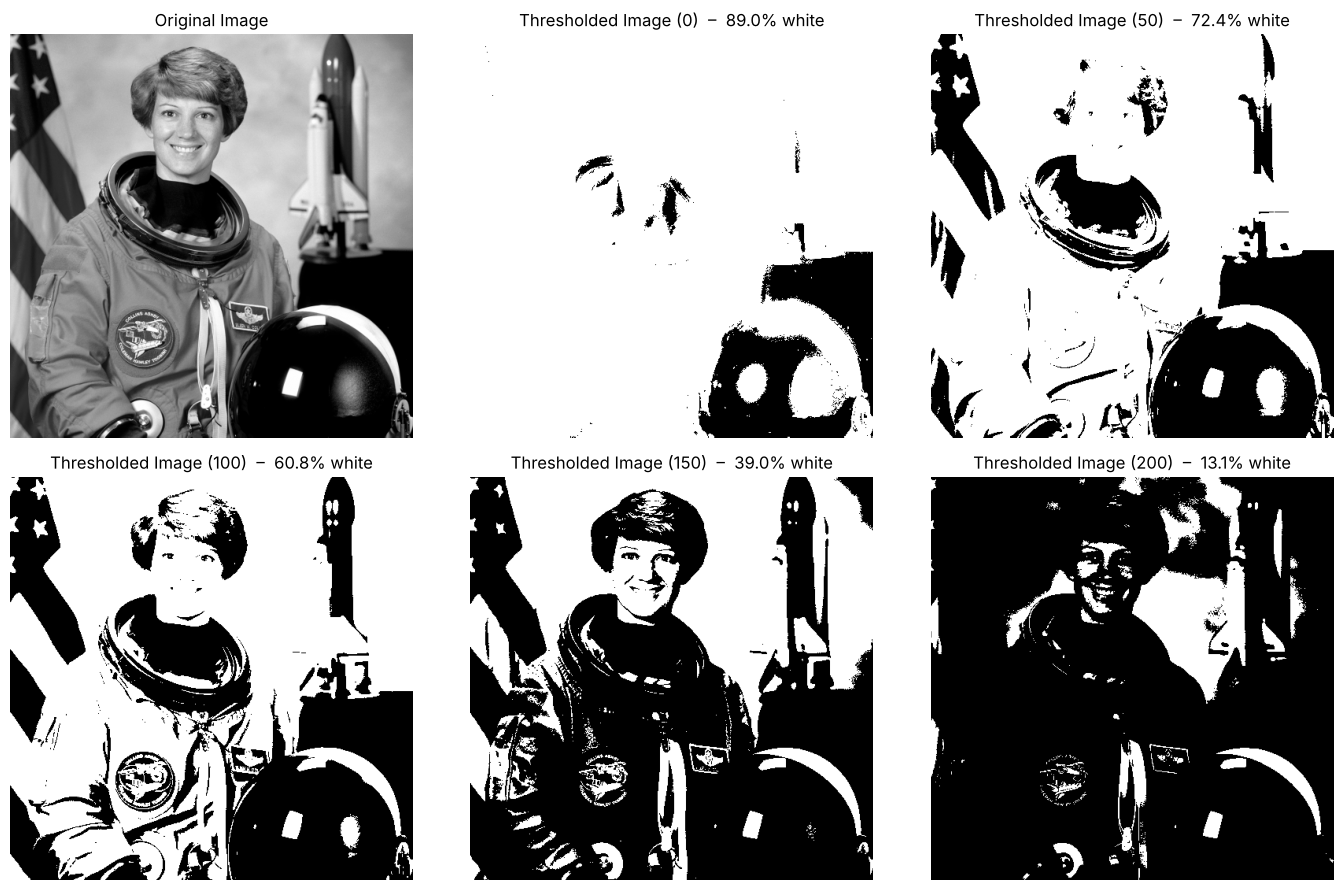

In [3]:
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
results = {}
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img_t, threshold_value, 255, cv2.THRESH_BINARY)
    results[threshold_value] = thresh

# Display the original image and every thresholded result
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()
axes[0].imshow(img_t, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image')
for ax, t in zip(axes[1:], threshold_values):
    ax.imshow(results[t], cmap='gray', vmin=0, vmax=255)
    white = 100 * np.count_nonzero(results[t]) / results[t].size
    ax.set_title(f'Thresholded Image ({t})  –  {white:.1f}% white')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observations**

* `T = 0` keeps most of the image white (about 89 %), because every pixel with a value greater than 0 is foreground; only pixels that are exactly 0 turn black. It carries almost no useful segmentation.
* As `T` increases, more pixels fall at or below the threshold and turn black, so the white (foreground) area shrinks. The percentage of white pixels in each title shows this.
* Very high thresholds (`T = 200`) keep only the brightest regions. The result is a detailed but sparse mask.
* A good threshold depends on lighting and image content, so it normally has to be tuned by trial, or chosen automatically (for example Otsu, or adaptive thresholding).

---
# Procedural Task 2 – Histogram Processing

**Step 1 – Load the necessary libraries.** The libraries are imported in the first cell
(`matplotlib`, `numpy`, `skimage.data`, `img_as_float`, `skimage.exposure`).

**Step 2 – Load the moon image.**

In [4]:
img = data.moon()
print('Shape:', img.shape, '| dtype:', img.dtype, '| min/max:', img.min(), '/', img.max())
print('Mean: %.2f | Std: %.2f' % (img.mean(), img.std()))

Shape: (512, 512) | dtype: uint8 | min/max: 0 / 255
Mean: 112.17 | Std: 13.33


**Step 3 – Contrast stretching.** Rescale the intensities so that the values between the
**2nd and 98th percentiles** are stretched to the full output range. Values below `p2` clip
to 0 and values above `p98` clip to 255, which makes the result robust to a few outlier pixels.

$$
g=\frac{f-p_{lo}}{p_{hi}-p_{lo}}\times 255
$$

In [5]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

print(f'2nd percentile  (p2)  = {p2}')
print(f'98th percentile (p98) = {p98}')
print('Original  range:', img.min(), '-', img.max())
print('Rescaled  range:', img_rescale.min(), '-', img_rescale.max())

2nd percentile  (p2)  = 78.0
98th percentile (p98) = 129.0
Original  range: 0 - 255
Rescaled  range: 0 - 255


**Step 4 – Display the image and its histogram** for the original (step 2) and the contrast-stretched image (step 3).

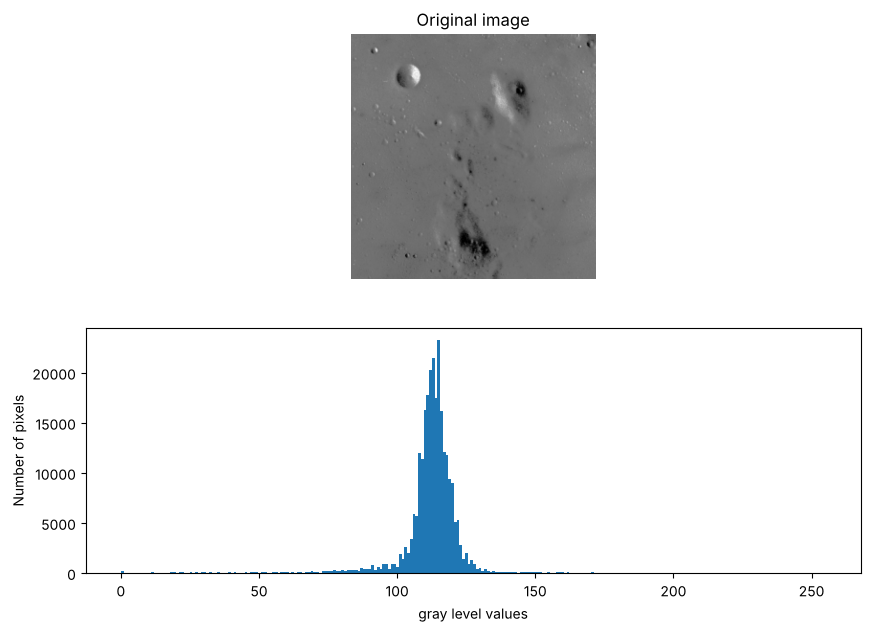

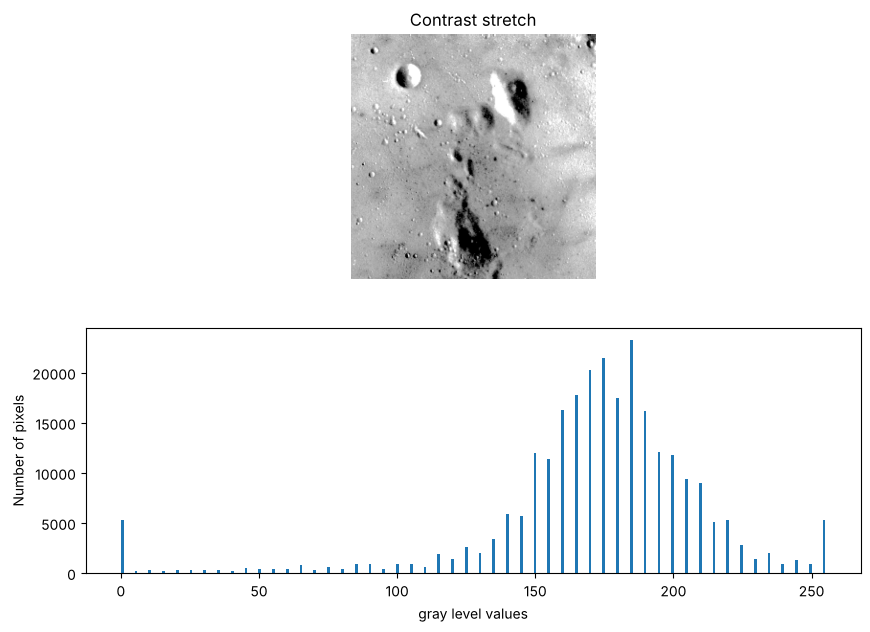

In [6]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

**Observations**

The original moon image is low-contrast: almost all pixels sit in a narrow band of gray levels
(roughly 78–129 for the 2nd–98th percentiles) and the histogram is a single tight peak. After
contrast stretching, that band is spread across 0–255, so the lunar surface detail is much
more visible. The histogram keeps the same *shape* (the transform is linear) but is wider and
sparser, with small spikes at 0 and 255 from the clipped 2 % tails.

---
# Assessment Task 1 – Contrast stretching with the 3rd and 80th percentiles

> *Using the same 'moon image', rescale intensity values to include all the intensities that fall within the 3rd and 80th percentiles, and plot the histogram.*

3rd percentile  (p3)  = 87.0
80th percentile (p80) = 118.0
Rescaled range: 0 - 255
Pixels clipped to 255: 21.0 %
Pixels clipped to 0  : 3.1 %


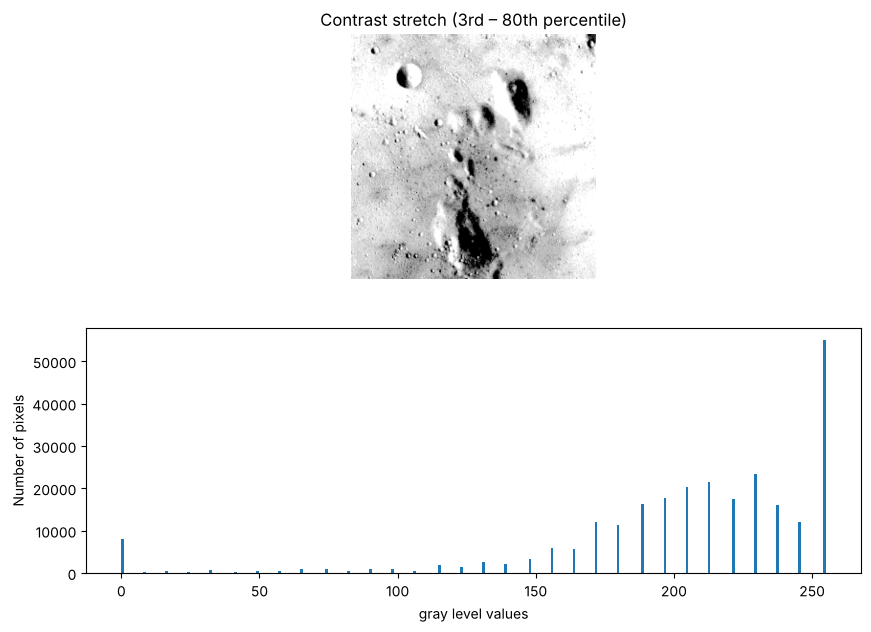

In [7]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

print(f'3rd percentile  (p3)  = {p3}')
print(f'80th percentile (p80) = {p80}')
print('Rescaled range:', img_rescale_3_80.min(), '-', img_rescale_3_80.max())
print('Pixels clipped to 255: %.1f %%' % (100 * np.mean(img_rescale_3_80 == 255)))
print('Pixels clipped to 0  : %.1f %%' % (100 * np.mean(img_rescale_3_80 == 0)))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd – 80th percentile)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

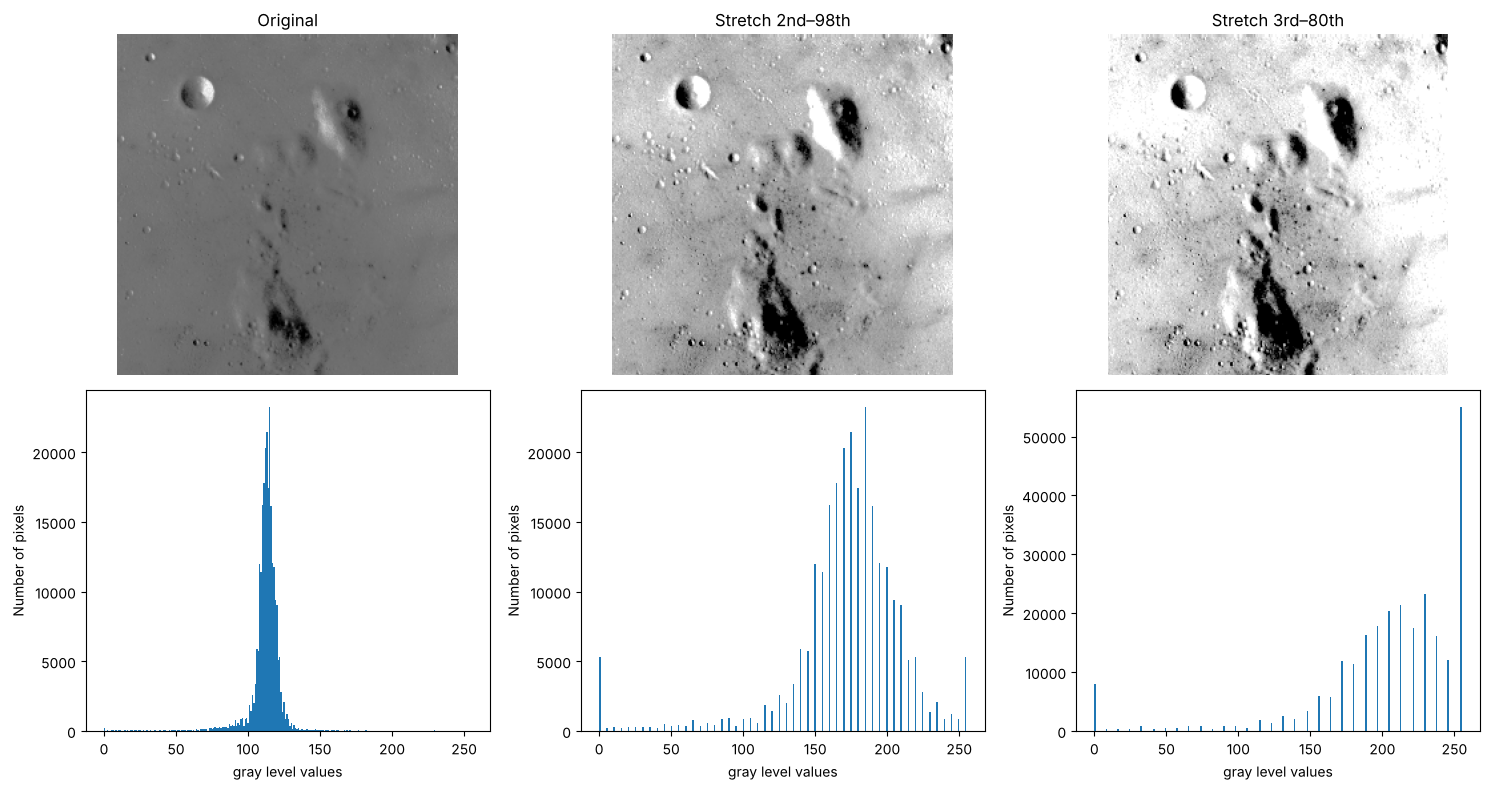

In [8]:
# Side-by-side comparison of the two stretches (2-98 vs 3-80)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
items = [(img, 'Original'),
         (img_rescale, 'Stretch 2nd–98th'),
         (img_rescale_3_80, 'Stretch 3rd–80th')]
for col, (im, title) in enumerate(items):
    axes[0, col].imshow(im, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(title)
    axes[0, col].axis('off')
    axes[1, col].hist(im.flat, bins=256, range=(0, 255))
    axes[1, col].set_xlabel('gray level values')
    axes[1, col].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

**Observations**

* The 3rd–80th percentile window is much *narrower* (about 87–118) than the 2nd–98th window (78–129), so the stretching factor is larger and the image looks more contrasty.
* Because the upper cut-off is the 80th percentile, **20 % of the pixels are above the window and saturate to white** (about 21 % of the pixels end up at exactly 255, against about 2 % for the 2–98 stretch). Bright details are lost: the brightest lunar surface regions turn to flat white.
* The histogram is spread over the full 0–255 range with a tall spike at 255 for the saturated pixels and a small one at 0.
* **Trade-off:** a narrower percentile window gives stronger contrast but clips more information. A wider window such as 2–98 keeps more detail.

---
# Assessment Task 2 – Histogram equalization

> *Using the same 'moon image' and the `exposure.equalize_hist` function, display the image and the histogram of the image after flattening the histogram.*

Histogram equalization maps the intensities with the cumulative distribution function (CDF)
of the image, $s_k = T(r_k) = (L-1)\sum_{j\le k} p_r(r_j)$, so that the output histogram is
approximately uniform ("flat"). `exposure.equalize_hist` returns a **float image in [0, 1]**,
so the histogram is plotted over the range (0, 1).

dtype: float64 | range: 0.001 - 1.000
Std before: 13.33 / 255 = 0.052   |   Std after: 0.290
(A perfectly uniform distribution on [0,1] has std = 0.289)


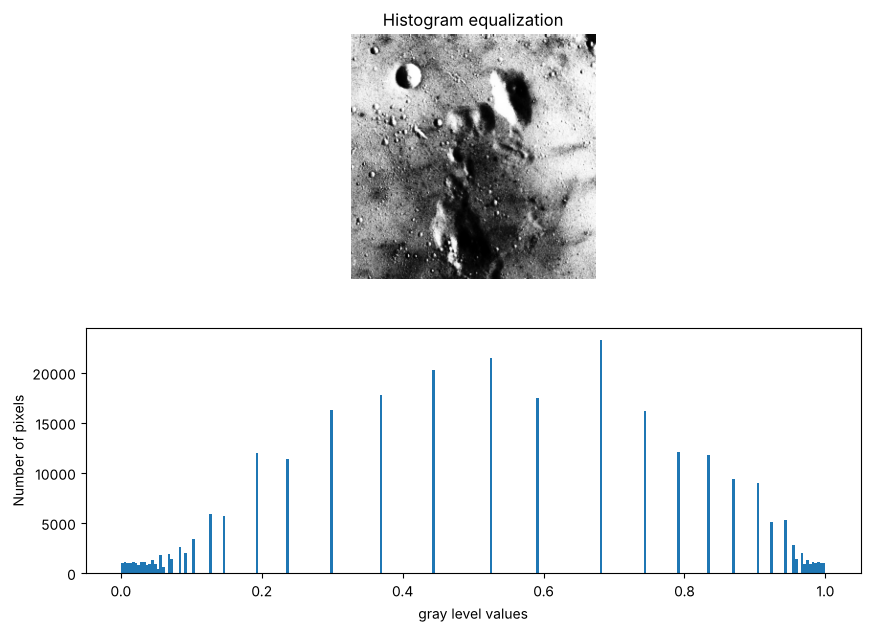

In [9]:
img_eq = exposure.equalize_hist(img)

print('dtype:', img_eq.dtype, '| range: %.3f - %.3f' % (img_eq.min(), img_eq.max()))
print('Std before: %.2f / 255 = %.3f   |   Std after: %.3f' % (img.std(), img.std() / 255, img_eq.std()))
print('(A perfectly uniform distribution on [0,1] has std = %.3f)' % (1 / np.sqrt(12)))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

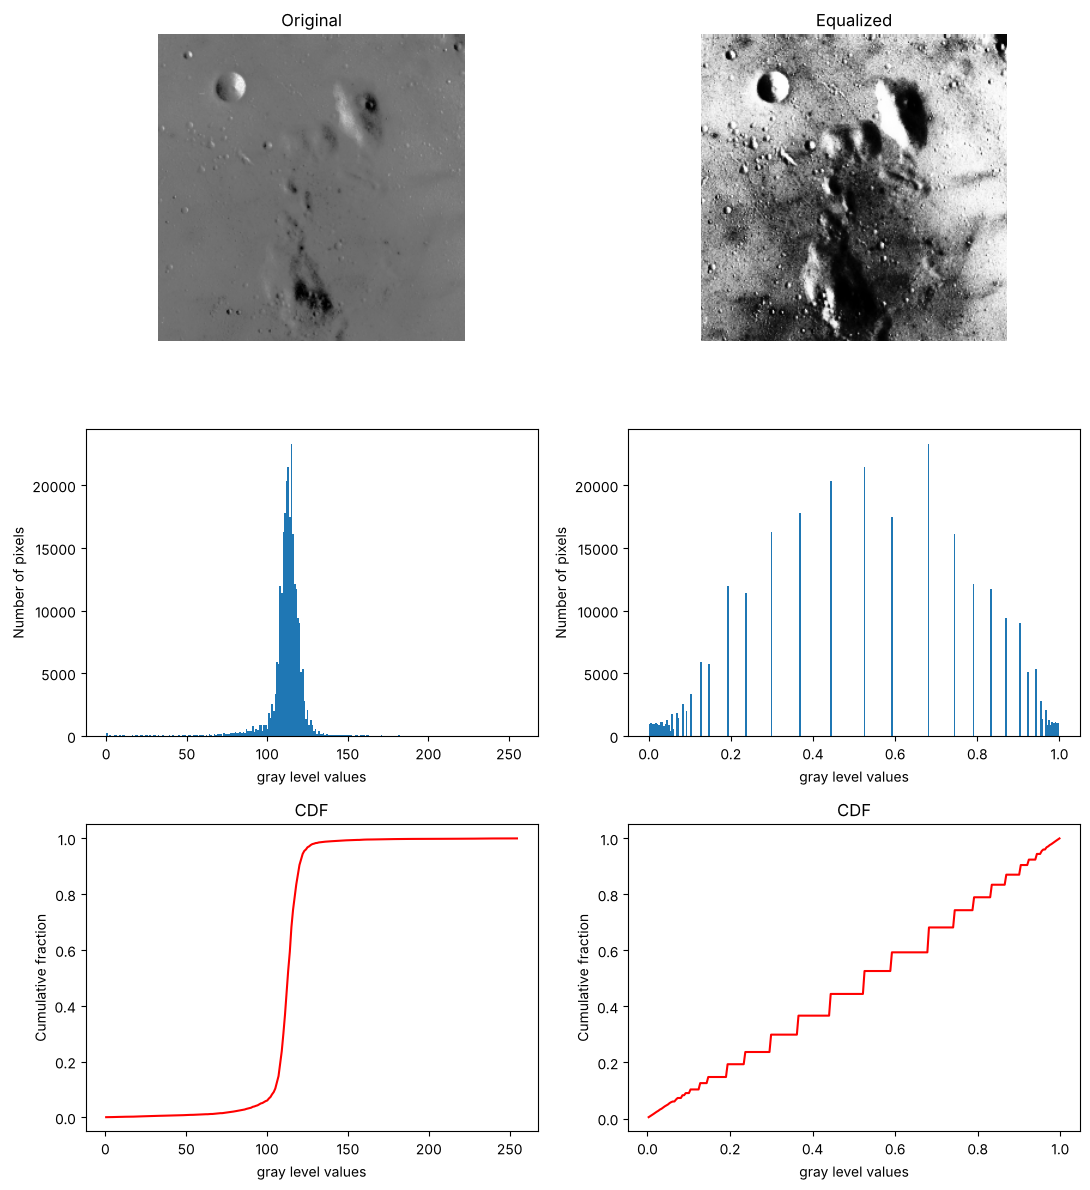

In [10]:
# Before / after: image, histogram and cumulative distribution
img_f = img_as_float(img)
cdf_before, bins_before = exposure.cumulative_distribution(img_f)
cdf_after,  bins_after  = exposure.cumulative_distribution(img_eq)

fig, axes = plt.subplots(3, 2, figsize=(11, 12))
for col, (im, title, rng, cdf, bins) in enumerate([
        (img,    'Original',     (0, 255), cdf_before, bins_before * 255),
        (img_eq, 'Equalized',    (0, 1),   cdf_after,  bins_after)]):
    axes[0, col].imshow(im, cmap='gray')
    axes[0, col].set_title(title)
    axes[0, col].axis('off')
    axes[1, col].hist(im.flat, bins=256, range=rng)
    axes[1, col].set_xlabel('gray level values')
    axes[1, col].set_ylabel('Number of pixels')
    axes[2, col].plot(bins, cdf, 'r')
    axes[2, col].set_xlabel('gray level values')
    axes[2, col].set_ylabel('Cumulative fraction')
    axes[2, col].set_title('CDF')
plt.tight_layout()
plt.show()

**Observations**

* The equalized histogram is far more spread out than the original single narrow peak, and the CDF becomes close to the straight diagonal line that characterizes a uniform histogram.
* Local contrast improves strongly: craters and surface texture are much easier to see than in the original image.
* The histogram is *approximately* flat, not perfectly flat. Gray levels are discrete, and every pixel with the same input value must map to the same output value, so equalization cannot split a populated bin. That leaves gaps and spikes in the histogram.
* Unlike contrast stretching (a linear mapping), equalization is **non-linear** and has no parameters. It can over-amplify noise in nearly uniform regions, so the image may look harsher than a stretched version.

---
# Assessment Task 3 – Histogram matching

> *Use the rocket (as reference) and Chelsea images (from `skimage.data`) and implement histogram matching.*

Histogram matching (specification) adjusts the **source** image so that its histogram follows
the histogram of a **reference** image. Here:

* **Source / image to adjust:** `data.chelsea()` (the cat, warm and bright)
* **Reference:** `data.rocket()` (dark, bluish-green)

`exposure.match_histograms` computes the cumulative histogram of the source and of the reference
and, for each source level, selects the reference level with the same cumulative probability.
For RGB images, each channel is matched independently (`channel_axis=-1`).

Source    : (300, 451, 3) uint8
Reference : (427, 640, 3) uint8
Matched   : (300, 451, 3) uint8


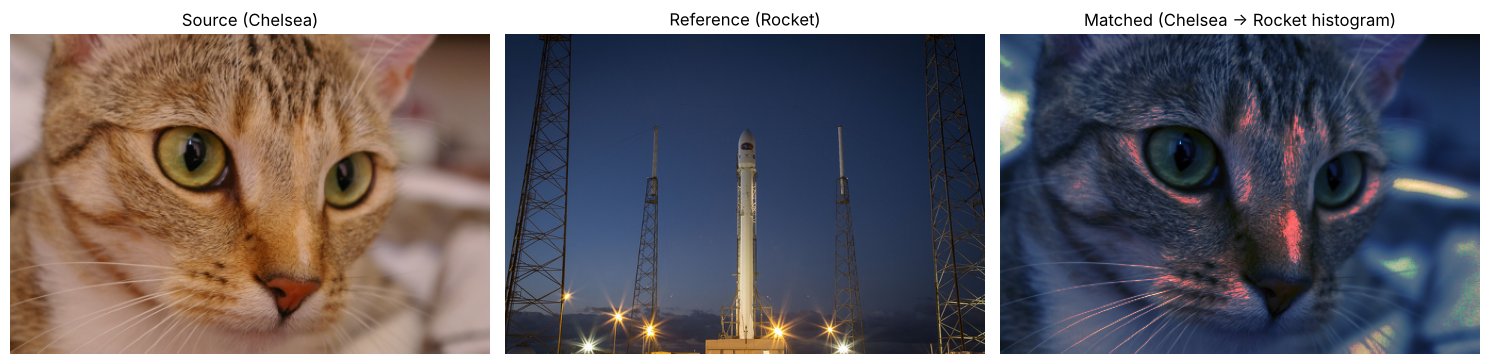

In [11]:
reference = data.rocket()    # reference image
image     = data.chelsea()   # image to be matched

matched = exposure.match_histograms(image, reference, channel_axis=-1)

print('Source    :', image.shape,     image.dtype)
print('Reference :', reference.shape, reference.dtype)
print('Matched   :', matched.shape,   matched.dtype)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5))
for aa in (ax1, ax2, ax3):
    aa.set_axis_off()
ax1.imshow(image);     ax1.set_title('Source (Chelsea)')
ax2.imshow(reference); ax2.set_title('Reference (Rocket)')
ax3.imshow(matched);   ax3.set_title('Matched (Chelsea → Rocket histogram)')
plt.tight_layout()
plt.show()

**Verification – the cumulative histograms of the matched image should lie on top of the reference.**

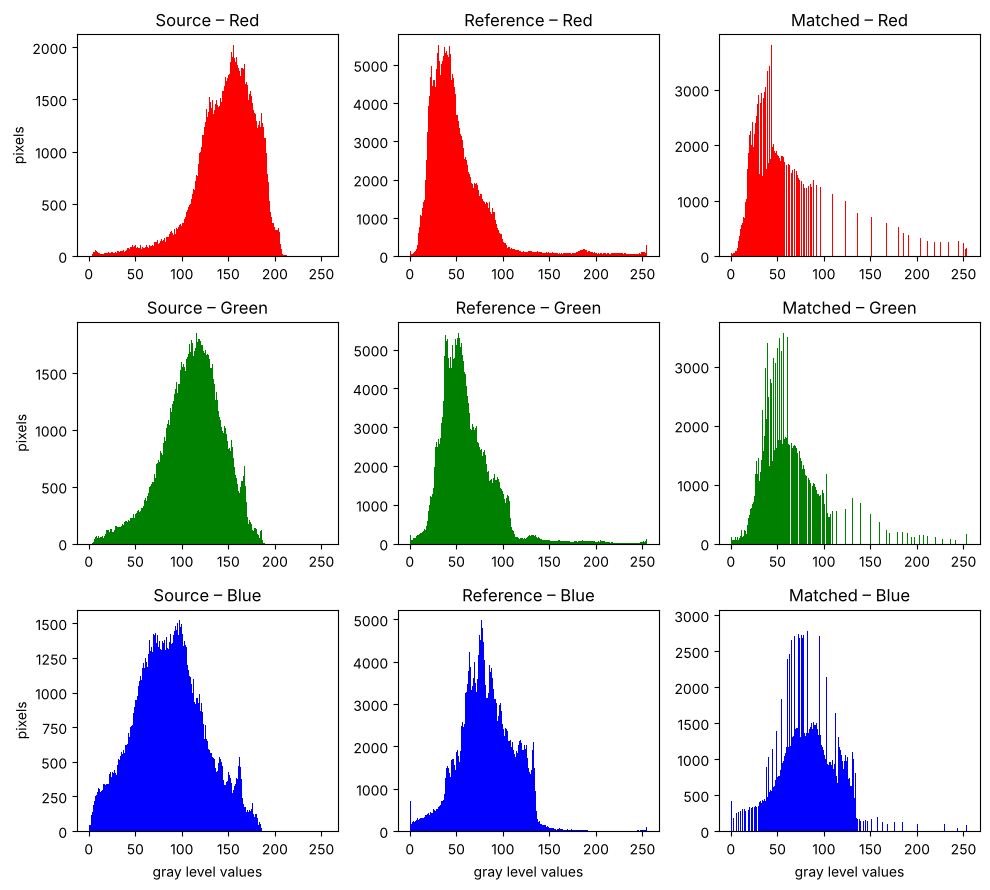

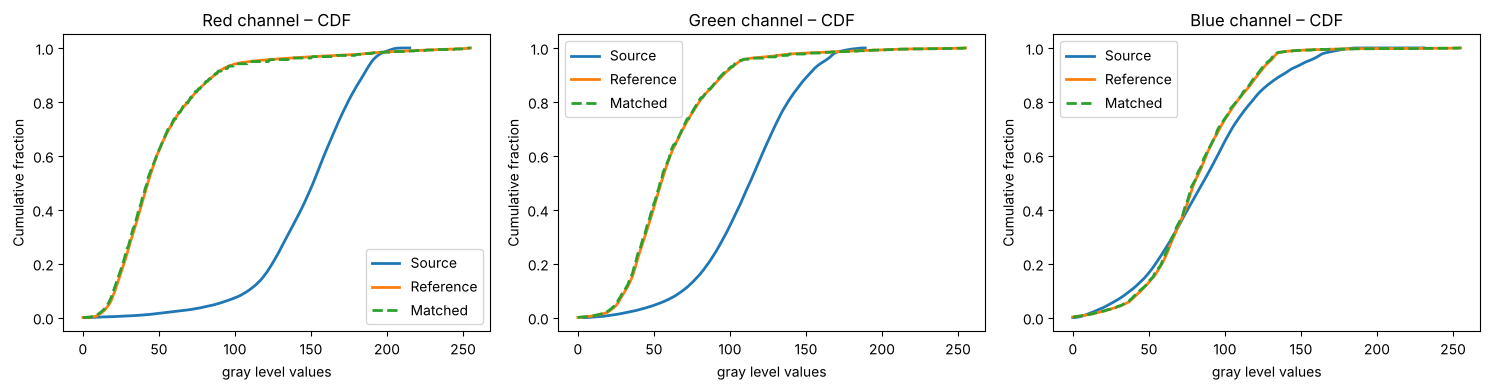

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 9))
channel_names = ['Red', 'Green', 'Blue']

for i, name in enumerate(channel_names):
    for col, (im, label) in enumerate([(image, 'Source'),
                                       (reference, 'Reference'),
                                       (matched, 'Matched')]):
        # histogram of the channel
        axes[i, col].hist(im[..., i].ravel(), bins=256, range=(0, 255),
                          color=name.lower())
        axes[i, col].set_title(f'{label} – {name}')
        axes[i, col].set_xlabel('gray level values') if i == 2 else None
        axes[i, col].set_ylabel('pixels') if col == 0 else None
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
for i, name in enumerate(channel_names):
    for im, label, style in [(image, 'Source', '-'),
                             (reference, 'Reference', '-'),
                             (matched, 'Matched', '--')]:
        cdf, bins = exposure.cumulative_distribution(im[..., i])
        axes[i].plot(bins, cdf, style, label=label, linewidth=2)
    axes[i].set_title(f'{name} channel – CDF')
    axes[i].set_xlabel('gray level values')
    axes[i].set_ylabel('Cumulative fraction')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [13]:
# Numerical check: per-channel mean intensity (R, G, B)
import pandas as pd
table = pd.DataFrame({
    'Source (Chelsea)':   image.mean(axis=(0, 1)),
    'Reference (Rocket)': reference.mean(axis=(0, 1)),
    'Matched':            matched.mean(axis=(0, 1)),
}, index=['R', 'G', 'B']).round(2)
print(table.to_string())

# The matched image should be much closer to the reference than the source is
d_before = np.abs(image.mean(axis=(0, 1))   - reference.mean(axis=(0, 1))).sum()
d_after  = np.abs(matched.mean(axis=(0, 1)) - reference.mean(axis=(0, 1))).sum()
print(f'\nSum of |mean differences| to the reference: before = {d_before:.2f}, after = {d_after:.2f}')
assert d_after < d_before

   Source (Chelsea)  Reference (Rocket)  Matched
R            147.67               52.27    52.05
G            111.44               61.29    60.82
B             86.80               82.27    81.74

Sum of |mean differences| to the reference: before = 150.08, after = 1.21


**Observations**

* The source image is bright and warm (high red mean). After matching, its colour distribution follows the rocket image: the picture becomes darker and shifts toward blue/teal, even though its content and shape are unchanged. Some pinkish-red patches remain on the nose and fur, where the independently matched channels no longer agree on colour.
* The CDF curves of the matched image (dashed) lie essentially on top of the reference curves in all three channels, which confirms that the histograms were matched.
* The per-channel mean intensities of the matched image are within about 1 gray level of the reference, whereas the source differs from the reference by roughly 95 levels in red.
* Matching is done **per channel**, so it can change colour balance and produce an unnatural colour cast. It is useful for normalizing images taken under different lighting conditions before further processing.

---
# Summary

| Technique | Mapping | Result on the moon / test images |
|---|---|---|
| Fixed thresholding | binary, `f > T` | White area shrinks as `T` increases |
| Contrast stretching (2–98) | linear, clips 2 % tails | Contrast improved with little information lost |
| Contrast stretching (3–80) | linear, clips 3 % + 20 % tails | Stronger contrast but ~20 % of pixels saturate |
| Histogram equalization | non-linear, CDF of the image | Approximately flat histogram, maximum global contrast |
| Histogram matching | CDF of source → inverse CDF of reference | Source takes the intensity/colour distribution of the reference |